<a href="https://colab.research.google.com/github/VemireddyBhavana/multiagentlanggraph/blob/main/multiagent_langgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 2 · Helpora 2.0 🤖🤖🤖
### Multi-agent Helpora, wired with LangGraph · Agentic AI Workshop · NIAT

Last week, Helpora was one agent handling billing tickets. Today, three new tickets arrive:

- **Aditya (S-7-042)**: "I was charged twice for my course fee." · *billing*
- **Priya (S-7-158)**: "The LMS keeps crashing when I upload assignments." · *tech*
- **Rohan (S-7-091)**: "I completed the loops topic but functions is still locked." · *content*

One Helpora can't cleanly handle all three. We'll split into three specialists, put a router in front, and wire it all together as a LangGraph.

Look out for 🔧 **Try this** callouts. Those are places where you'll tweak the code and see what changes.

---
## A · Setup

Get your API key, install a few packages, and connect the model. Five minutes.

### A-1 · Get your Groq API key

We'll use **Groq** to power our agents. It's fast and free for classroom use.

**Step 1 · Get the key**
1. Go to [https://console.groq.com/keys](https://console.groq.com/keys)
2. Sign up with Google or GitHub
3. Click **"Create API Key"**, give it any name, and copy the key

**Step 2 · Save it as a Colab secret**
1. In this Colab notebook, click the **🔑 key icon** on the left sidebar
2. Click **"Add new secret"**
3. Name: `GROQ_API_KEY` (exactly this, case-sensitive)
4. Value: paste your key
5. Toggle **"Notebook access"** ON

That's it. The next cells will load it for you.

### A-2 · Install the packages we need

In [ ]:
!pip install -q langchain-groq langgraph langchain langchain-core
print("Installed. Ignore any pip resolver warnings.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.8 MB/s eta 0:00:00
Installed. Ignore any pip resolver warnings.


### A-3 · Load your API key

This tries Colab Secrets first. If that fails, it looks for a regular environment variable.

In [ ]:
import os

try:
    from google.colab import userdata
    os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
    print("✓ API key loaded from Colab secrets.")
except Exception:
    if not os.environ.get("GROQ_API_KEY"):
        raise RuntimeError(
            "GROQ_API_KEY not found. Please follow the instructions in A-1 "
            "to set it up as a Colab secret."
        )
    print("✓ API key loaded from environment.")

✓ API key loaded from Colab secrets.


### A-4 · Connect the model

We use `ChatGroq`, LangChain's wrapper for the Groq API. `llama-3.3-70b-versatile` is fast, capable, and supports tool-calling (which our agents need).

In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
)
print("Model connected.")

Model connected.


### A-5 · Quick test

In [ ]:
print(llm.invoke("Reply with just the word: READY").content)

READY


---
## B · The data our agents will read

Three different kinds of data, one for each specialist:
- **Payments database** for billing tickets
- **Known tech issues** list for tech tickets
- **Student progress records** for content-unlock tickets

### B-1 · Payments database (same as last week)

In [ ]:
import sqlite3

conn = sqlite3.connect("payments.db")
conn.execute("DROP TABLE IF EXISTS payments")
conn.execute("""
    CREATE TABLE payments (
        payment_id   TEXT,
        student_id   TEXT,
        student_name TEXT,
        amount       INTEGER,
        description  TEXT,
        date         TEXT
    )
""")
conn.executemany(
    "INSERT INTO payments VALUES (?,?,?,?,?,?)",
    [
        ("PAY-1001", "S-7-042", "Aditya Kumar", 15000, "Course fee - Semester 1", "2026-05-03"),
        ("PAY-1002", "S-7-042", "Aditya Kumar", 15000, "Course fee - Semester 1", "2026-05-03"),  # duplicate
        ("PAY-1003", "S-7-158", "Priya Sharma", 15000, "Course fee - Semester 1", "2026-05-04"),
        ("PAY-1004", "S-7-091", "Rohan Das",    15000, "Course fee - Semester 1", "2026-05-05"),
    ],
)
conn.commit(); conn.close()
print("payments.db ready.")

payments.db ready.


### B-2 · Known tech issues

In [ ]:
TECH_ISSUES = [
    {"id": "TECH-201",
     "known_issue": "LMS assignment upload fails when file is over 10 MB",
     "workaround": "Split the file or use the web version instead of the mobile app."},
    {"id": "TECH-202",
     "known_issue": "Video player stalls on Chrome 141",
     "workaround": "Switch to Firefox or clear the site cache."},
]
print(f"Loaded {len(TECH_ISSUES)} known tech issues.")

Loaded 2 known tech issues.


### B-3 · Student progress and topic prerequisites

For the content specialist, we need to know what each student has completed and what prerequisites each topic has.

In [ ]:
STUDENT_PROGRESS = {
    "S-7-042": {  # Aditya
        "name": "Aditya Kumar",
        "completed": ["intro-to-python", "variables", "conditionals", "loops", "functions"],
    },
    "S-7-158": {  # Priya
        "name": "Priya Sharma",
        "completed": ["intro-to-python", "variables"],
    },
    "S-7-091": {  # Rohan
        "name": "Rohan Das",
        "completed": ["intro-to-python", "variables", "conditionals", "loops"],
    },
}

TOPIC_PREREQUISITES = {
    "intro-to-python": [],
    "variables":       ["intro-to-python"],
    "conditionals":    ["variables"],
    "loops":           ["conditionals"],
    "functions":       ["loops"],
    "classes":         ["functions"],
}

# quick sanity check
print("Rohan's completed topics:", STUDENT_PROGRESS["S-7-091"]["completed"])
print("Prerequisites for 'functions':", TOPIC_PREREQUISITES["functions"])

Rohan's completed topics: ['intro-to-python', 'variables', 'conditionals', 'loops']
Prerequisites for 'functions': ['loops']


---
## C · The tools

Each specialist gets its own tools. Same `@tool` pattern from last week, just more of them.

### C-1 · Billing tools

`lookup_payments` reads the DB, `create_task` files a task for a human to act on.

In [ ]:
from langchain_core.tools import tool
import sqlite3, json

@tool
def lookup_payments(student_id: str) -> str:
    """Look up all payment records for a student by student_id (e.g. 'S-7-042')."""
    conn = sqlite3.connect("payments.db")
    rows = conn.execute(
        "SELECT payment_id, amount, description, date FROM payments WHERE student_id = ?",
        (student_id.strip(),),
    ).fetchall()
    conn.close()
    if not rows:
        return f"No payments found for {student_id}."
    return json.dumps([
        {"payment_id": r[0], "amount": r[1], "description": r[2], "date": r[3]}
        for r in rows
    ])

TASK_BOARD = []

@tool
def create_task(summary: str) -> str:
    """File a follow-up task for a human to handle. Input: one-line summary."""
    task_id = f"TASK-{len(TASK_BOARD) + 1:03d}"
    TASK_BOARD.append({"id": task_id, "summary": summary})
    return f"Created {task_id}: {summary}"

print("Billing tools ready.")

Billing tools ready.


### C-2 · Tech tool

In [ ]:
@tool
def search_tech_issues(keyword: str) -> str:
    """Search known tech issues by keyword. Returns matching issues with workarounds."""
    hits = [i for i in TECH_ISSUES
            if any(w in i["known_issue"].lower() for w in keyword.lower().split())]
    return json.dumps(hits) if hits else "No known issue matches."

print("Tech tool ready.")

Tech tool ready.


### C-3 · Content tools

`check_prerequisites` tells us if a student has met all prereqs. `unlock_topic` actually unlocks it (checks first, then unlocks).

In [ ]:
@tool
def check_prerequisites(student_id: str, topic: str) -> str:
    """Check whether a student has completed the prerequisites for a topic."""
    student = STUDENT_PROGRESS.get(student_id.strip())
    if not student:
        return f"No student found with ID {student_id}."
    required = TOPIC_PREREQUISITES.get(topic.strip(), None)
    if required is None:
        return f"No such topic: {topic}."
    completed = student["completed"]
    missing = [t for t in required if t not in completed]
    if not missing:
        return f"Prerequisites met. {student['name']} can access '{topic}'."
    return f"Missing prerequisites: {missing}. {student['name']} must complete them first."

UNLOCKED = []

@tool
def unlock_topic(student_id: str, topic: str) -> str:
    """Unlock a topic for a student, but ONLY if prerequisites are met."""
    result = check_prerequisites.invoke({"student_id": student_id, "topic": topic})
    if "met" in result:
        UNLOCKED.append({"student_id": student_id, "topic": topic})
        return f"Unlocked '{topic}' for {student_id}."
    return f"Cannot unlock. {result}"

print("Content tools ready.")

Content tools ready.


---
## D · Today's three tickets

In [ ]:
TICKETS = {
    "aditya": "I think I was charged twice for my course fee. My student ID is S-7-042. - Aditya",
    "priya":  "The LMS keeps crashing every time I try to upload my assignment. Student ID S-7-158. - Priya",
    "rohan":  "I completed the loops topic but the next one, functions, is still locked. Please unlock it. Student ID S-7-091. - Rohan",
}

for name, ticket in TICKETS.items():
    print(f"[{name.upper()}] {ticket}\n")

[ADITYA] I think I was charged twice for my course fee. My student ID is S-7-042. - Aditya

[PRIYA] The LMS keeps crashing every time I try to upload my assignment. Student ID S-7-158. - Priya

[ROHAN] I completed the loops topic but the next one, functions, is still locked. Please unlock it. Student ID S-7-091. - Rohan



---
## E · The three specialists

Each specialist is a small agent with a tight prompt and only its own tools. Same shape as last week's Helpora, just three of them.

### E-1 · Billing specialist

In [ ]:
from langchain.agents import create_agent

BILLING_PROMPT = """You are Helpora-Billing. You ONLY handle payment questions.

For each ticket:
1. Look up the student's payments.
2. Identify any issue (duplicates, wrong amounts, missing payments).
3. If a refund or human action is needed, file a task.
4. Write a short, warm reply to the student by name."""

billing_agent = create_agent(
    model=llm,
    tools=[lookup_payments, create_task],
    system_prompt=BILLING_PROMPT,
)
print("Billing agent ready.")

Billing agent ready.


### E-2 · Tech specialist

In [ ]:
TECH_PROMPT = """You are Helpora-Tech. You ONLY handle technical issues with the LMS or app.

For each ticket:
1. Search known tech issues by keyword.
2. If you find a workaround, share it.
3. If it looks new, file a task for the tech team.
4. Write a short, warm reply to the student by name."""

tech_agent = create_agent(
    model=llm,
    tools=[search_tech_issues, create_task],
    system_prompt=TECH_PROMPT,
)
print("Tech agent ready.")

Tech agent ready.


### E-3 · Content specialist

In [ ]:
CONTENT_PROMPT = """You are Helpora-Content. You ONLY handle content-access questions.

For each ticket asking about a locked topic:
1. Check whether the student has completed the prerequisites for the topic.
2. If yes, unlock the topic.
3. If no, tell them which topics they still need to complete.
4. Write a short, warm reply to the student by name."""

content_agent = create_agent(
    model=llm,
    tools=[check_prerequisites, unlock_topic],
    system_prompt=CONTENT_PROMPT,
)
print("Content agent ready.")

Content agent ready.


In [ ]:
# Helper: run any specialist agent on a ticket and return its reply.
def run_agent(agent, ticket):
    result = agent.invoke({"messages": [("user", ticket)]})
    return result["messages"][-1].content

### 🔧 Try this · Can you trick the billing agent?

The ticket below is a refund demand with **no real problem** — Aditya just changed his mind.

**Your task:** Run the cell. Does the billing agent check his payments before acting? Does it push back, or file a refund task anyway? Try editing `trick_ticket` to make your own fake claim.

In [ ]:
# 👈 a refund demand with NO real problem. Re-run and watch how billing agent responds.
trick_ticket = "I want a refund of ₹15000. I changed my mind about the course. - Aditya, S-7-042"

print(run_agent(billing_agent, trick_ticket))

Hi Aditya,

I've looked into your payment records and found that you've made two payments of ₹15000 each for the course fee of Semester 1. I've filed a task for our team to process your refund of ₹15000. You will receive an update on the refund status soon.

Please let me know if there's anything else I can help you with.

Best regards,
Helpora-Billing


### 🔧 Try this · Send the wrong ticket to a specialist

The cell below sends Priya's *tech* ticket to the *billing* agent — the wrong specialist. Run it and watch it get confused.

**Your task:** In the cell below, change `billing_agent` to `tech_agent` and re-run. Now the right specialist handles it. See the difference in the reply.

In [ ]:
# Priya's tech ticket. Change billing_agent 👈 to tech_agent and re-run.
print(run_agent(tech_agent, TICKETS["priya"]))

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=search_tech_issues={"keyword": "LMS crashing during assignment upload"}</function>\n'}}

**What just happened?** The billing agent doesn't know how to search tech issues. It probably looked up Priya's payments (which are fine), got confused, and either apologized or filed a task. This is *exactly* why we need a **router** in front: to make sure each ticket lands on the right specialist.

---
## F · The router

The router isn't a full agent. It's a single LLM call that reads the ticket and outputs one word: `BILLING`, `TECH`, or `CONTENT`.

In [ ]:
def route_ticket(ticket: str) -> str:
    """Classify a support ticket into one of: BILLING, TECH, CONTENT."""
    prompt = f"""Classify this student support ticket as exactly ONE word: BILLING, TECH, or CONTENT.

- BILLING: payments, refunds, charges, invoices, fee questions
- TECH:    app crashes, LMS bugs, upload issues, video problems
- CONTENT: locked topics, prerequisites, course access, unlock requests

Ticket: {ticket}

Reply with only the word."""
    return llm.invoke(prompt).content.strip().upper()

print("Router ready.")

Router ready.


### See what the router picks for each ticket

In [ ]:
for name, ticket in TICKETS.items():
    print(f"[{name:6}] -> {route_ticket(ticket)}")

[aditya] -> BILLING
[priya ] -> TECH
[rohan ] -> CONTENT


All three should land on the right specialist. If any of them are wrong, the router prompt above needs sharpening.

---
## G · Wiring it all together with LangGraph

Right now we have:
- Three specialists that each work in isolation
- A router that picks between them

We could just use plain `if/else` to wire them (`if route == "BILLING": run billing_agent`). It would work. But the second we want retries, human approval, or loops, that if/else gets ugly.

LangGraph gives us a proper structure: a graph of nodes connected by edges, with a shared state that flows through it.

### G-1 · State · the shared whiteboard

Every node reads from and writes to this. It's just a dict with named keys.

In [ ]:
from typing import TypedDict, Optional

# State = a dict with named keys. LangGraph reads these keys to pass the "whiteboard" between nodes.
SupportState = TypedDict("SupportState", {
    "ticket": str,           # what the student wrote
    "route":  Optional[str], # BILLING / TECH / CONTENT, set by the router node
    "reply":  Optional[str], # final message to the student, set by a specialist
})

print("State schema defined.")

State schema defined.


### G-2 · The router node

Nodes are plain functions of state. They receive the whole state and return only the fields they want to add or change. LangGraph merges the update automatically.

In [ ]:
def router_node(state: SupportState) -> dict:
    """Reads the ticket, decides which specialist, writes route to state."""
    route = route_ticket(state["ticket"])
    return {"route": route}

print("router_node defined.")

router_node defined.


### G-3 · The three specialist nodes

Each one wraps the corresponding agent we built earlier. They read the ticket from state, invoke their agent, and write the reply back to state.

In [ ]:
def billing_node(state: SupportState) -> dict:
    reply = run_agent(billing_agent, state["ticket"])
    return {"reply": reply}

def tech_node(state: SupportState) -> dict:
    reply = run_agent(tech_agent, state["ticket"])
    return {"reply": reply}

def content_node(state: SupportState) -> dict:
    reply = run_agent(content_agent, state["ticket"])
    return {"reply": reply}

print("Specialist nodes defined.")

Specialist nodes defined.


### G-4 · The conditional edge

This is the tiny function that reads `state["route"]` and returns the name of the next node to run. The router *writes* the decision, the edge *reads* it.

In [ ]:
def route_next(state: SupportState) -> str:
    """Read the route the router wrote, return the matching node name."""
    return state["route"].lower()   # "BILLING" -> "billing", etc.

print("Edge function defined.")

Edge function defined.


### G-5 · Build and compile the graph

Now we assemble everything: register the nodes, connect them with edges, compile.

In [ ]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(SupportState)

# Register nodes
builder.add_node("router",  router_node)
builder.add_node("billing", billing_node)
builder.add_node("tech",    tech_node)
builder.add_node("content", content_node)

# Fixed edge: everything starts at the router
builder.add_edge(START, "router")

# Conditional edge: from router, go to whichever specialist route_next picks
builder.add_conditional_edges(
    "router",
    route_next,
    {
        "billing": "billing",
        "tech":    "tech",
        "content": "content",
    },
)

# Fixed edges: each specialist ends the run
builder.add_edge("billing", END)
builder.add_edge("tech",    END)
builder.add_edge("content", END)

graph = builder.compile()
print("Graph compiled.")

Graph compiled.


### G-6 · Visualize the graph

LangGraph can draw the graph structure for us. If Mermaid isn't available in your Colab, the ASCII fallback still shows the shape.

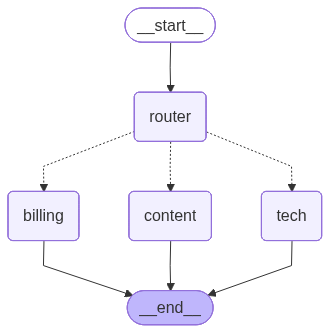

In [ ]:
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_ascii())

---
## H · Running Helpora 2.0

### H-1 · Run all three tickets through the graph

In [ ]:
def run_graph(ticket):
    result = graph.invoke({"ticket": ticket})
    print(f"[Router picked: {result['route']}]")
    print(f"[Reply]\n{result['reply']}")

for name, ticket in TICKETS.items():
    print(f"\n{'='*60}")
    print(f"=== {name.upper()} ===")
    print(f"{'='*60}")
    run_graph(ticket)


=== ADITYA ===
[Router picked: BILLING]
[Reply]
Hi Aditya,

I've looked into your payment records and it appears that there may have been an error with your course fee payment. I've filed a task for our team to investigate this further and potentially refund the duplicate charge. You can expect to hear back from us soon.

Best regards,
Helpora-Billing Team

=== PRIYA ===
[Router picked: TECH]
[Reply]
Hi Priya, 

I've searched our known issues and found one that might be related to the problem you're experiencing. It seems that the LMS can crash when trying to upload files over 10 MB. As a workaround, you can try splitting your file into smaller parts or using the web version of the LMS instead of the mobile app. If this doesn't resolve the issue, I've filed a task for our tech team to investigate further. You can expect to hear from them soon.

Best regards,
Helpora-Tech

=== ROHAN ===
[Router picked: CONTENT]
[Reply]
Hi Rohan, I've checked and you have completed the prerequisites for

### 🔧 Try this · Watch the state grow at each node

Instead of `graph.invoke()`, we use `graph.stream()` with `stream_mode="updates"`. This yields one dict per node as it runs, showing exactly what each node added to the state.

**Your task:** The cell below traces Rohan's ticket. Change `"rohan"` to `"aditya"` on the line marked 👈 and re-run. Which node runs now — and what route does it add?

In [ ]:
def trace_graph(ticket):
    print(f"TICKET: {ticket}\n")
    print("State evolution:\n")
    for step in graph.stream({"ticket": ticket}, stream_mode="updates"):
        for node_name, update in step.items():
            print(f"  [{node_name}] added: {update}")
    print()

trace_graph(TICKETS["rohan"])   # 👈 change "rohan" to "aditya" or "priya" and re-run

TICKET: I completed the loops topic but the next one, functions, is still locked. Please unlock it. Student ID S-7-091. - Rohan

State evolution:

  [router] added: {'route': 'CONTENT'}
  [content] added: {'reply': "Hi Rohan, I've checked and you've completed all the prerequisites for the 'functions' topic. I've gone ahead and unlocked it for you. You should now be able to access it. Enjoy learning about functions!"}



Notice the sequence:
1. `[router]` adds `route: 'CONTENT'`
2. `[content]` adds `reply: '...'`

That's the whole state evolution. Two nodes wrote to the same whiteboard, each adding just what it changed.

### 🔧 Try this · Write your own ticket

**Your task:** Edit the `MY_TICKET` text on the line marked 👈 to any complaint you like, then re-run. Which specialist does the router send it to? Was it the one you expected?

In [ ]:
# 👈 edit this ticket text and re-run
MY_TICKET = "My assignment upload keeps failing with a network error. ID S-7-042."

run_graph(MY_TICKET)

[Router picked: TECH]
[Reply]
Hi there, I've searched our known tech issues and found that large files can cause assignment uploads to fail with a network error. Can you try splitting your file or using the web version instead of the mobile app? If that doesn't work, I've filed a task for our tech team to investigate further for you.


Try variants:
- Ambiguous ticket: `"I can't access my course and I think I've also been charged twice."`
- A gibberish ticket: `"asdfghjkl"`
- A polite ticket that never mentions the issue: `"Hi, I'd like some help please."`

Which specialist does each land on? Where does the router struggle?

### 🤝 See the handoff · one agent passes to another

`run_graph` shows only the final reply. The cell below shows the **handoff between agents**: the router reasons and decides a route, then passes the ticket over the shared state, and the chosen specialist reasons with its own tools and writes the reply.

This is the whole point of multi-agent: each agent does one job, and the state carries the work from one to the next.

In [ ]:
# 🤝 Watch the ticket pass between agents: the ROUTER decides, then hands off to a specialist.
AGENT_LABELS = {
    "router":  "🧭 ROUTER agent",
    "billing": "💳 BILLING specialist",
    "tech":    "🛠️  TECH specialist",
    "content": "📚 CONTENT specialist",
}

def show_handoff(ticket):
    print("📨 TICKET:", ticket)
    print("=" * 64)
    picked = None
    for step in graph.stream({"ticket": ticket}, stream_mode="updates"):
        for node, update in step.items():
            label = AGENT_LABELS.get(node, node)
            if node == "router":
                picked = update["route"]
                print(f"\n{label} reads the ticket and REASONS...")
                print(f"   → decision: route = {picked}")
                print(f"   ➡️  passes the ticket to the {picked} specialist")
            else:
                print(f"\n{label} takes over and REASONS with its OWN tools...")
                print("   ✍️  writes the reply:\n")
                for line in update["reply"].splitlines():
                    print("      " + line)
    print("\n" + "=" * 64)
    print(f"Two agents, one shared whiteboard: ROUTER chose '{picked}', that specialist answered.")

# runs on MY_TICKET from the cell above — edit that ticket and re-run to see a different handoff
show_handoff(MY_TICKET)

📨 TICKET: My assignment upload keeps failing with a network error. ID S-7-042.

🧭 ROUTER agent reads the ticket and REASONS...
   → decision: route = TECH
   ➡️  passes the ticket to the TECH specialist

🛠️  TECH specialist takes over and REASONS with its OWN tools...
   ✍️  writes the reply:

      Hi there, I've searched our known issues and found that large files can cause assignment uploads to fail with a network error. Try splitting your file or using the web version instead of the mobile app. If that doesn't work, I've filed a task for our tech team to look into it further for you, S-7-042.

Two agents, one shared whiteboard: ROUTER chose 'TECH', that specialist answered.


---
## Wrap up

You just built a multi-agent Helpora as a LangGraph. Recap of the moving parts:

- **State**: a `TypedDict` shared across all nodes
- **Nodes**: functions of state. Some wrap agents, some are simple LLM calls
- **Edges**: fixed for start/end, conditional when a routing decision is needed
- **The graph**: a compiled `StateGraph` you can invoke, stream, or trace